In [176]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [177]:
import numpy as np
import os
import matplotlib.pyplot as plt

# add path to the directory containing the module
cwd = os.getcwd()
# parent directory
parent = os.path.dirname(cwd)
import sys
sys.path.append(parent)
from utils import data

In [178]:
# data_dir = '../data/old-202403/processed data/'
data_dir = '/media/carsen/ssd1/github/SuperiorColliculus/data/Dublin/2024-05-24/'
filenames = os.listdir(data_dir)
print(filenames)

['rois.id.npy', 'calcium.timestamps.npy', 'circles.endTime.npy', 'wheel.timestamps.npy', 'circles.startTime.npy', 'body.timestamps.npy', 'Readme.txt.txt', 'NImages.zip', 'spout.licks.npy', 'suite2p', 'natural.fileIndex.npy', 'naturalExp.intervals.npy', 'natural.endTime.npy', 'planes.zTrace.npy', 'circles.y.npy', 'spout.timestamps.npy', 'natural.startTime.npy', 'circles.duration.npy', 'calcium.isZCorrected.npy', 'calcium.dff.npy', 'fullField.endTime.npy', 'circles.isWhite.npy', 'imglist.csv', 'fullFieldExp.intervals.npy', 'rois.xyz.npy', 'planes.zcorrelation.npy', 'circles.diameter.npy', 'circles.x.npy', 'fullField.startTime.npy', 'NImages', 'wheel.velocity.npy', 'rois.zProfiles.npy', 'eye.timestamps.npy', 'planes.delay.npy', 'fullField.stim.npy', 'circlesExp.intervals.npy', 'rois.planes.npy']


In [179]:
for filename in filenames:
    if '.npy' not in filename:
        continue
    if filename == 'natural.fileNames.npy':
        dat = np.load(data_dir + filename)
        print(filename, dat.shape)
    elif filename in ['imgs_cut.npy', 'natural.fileIndex.npy']:
        dat = np.load(data_dir + filename, allow_pickle=True)
        print(filename, dat.shape)
    else:
        dat = np.load(data_dir + filename, allow_pickle=True)
        print(filename, dat.shape, dat.min(), dat.max())

rois.id.npy (23,) 0 81
calcium.timestamps.npy (72755, 1) nan nan
circles.endTime.npy (8960, 1) 1020.139 1916.0479999999998
wheel.timestamps.npy (1288954, 1) 1.3591314385370499 2428.0259557793097
circles.startTime.npy (8960, 1) 1020.047 1915.942
body.timestamps.npy (144638, 1) nan nan
spout.licks.npy (2428066, 1) nan nan
natural.fileIndex.npy (3000, 1)
naturalExp.intervals.npy (1, 2) 60.256 1009.818
natural.endTime.npy (3000, 1) 60.264 1009.818
planes.zTrace.npy (1, 72755) 0 10
circles.y.npy (8960, 1) 5.0 40.0
spout.timestamps.npy (2428066, 1) 0.0 2428.063
natural.startTime.npy (3000, 1) 60.256 1009.657
circles.duration.npy (8960, 1) 0.1 0.1
calcium.isZCorrected.npy (23,) True True
calcium.dff.npy (72755, 23) nan nan
fullField.endTime.npy (130, 1) 1942.1309999999999 2421.098
circles.isWhite.npy (8960, 1) 0.0 1.0
fullFieldExp.intervals.npy (1, 2) 1939.109 2421.098
rois.xyz.npy (23, 3) -0.0003315036678639416 436.0
planes.zcorrelation.npy (1, 100, 72755) 0.0011918979 0.032994207
circles.di

# load image data

In [180]:
# load the image indexes
csv_file_path = os.path.join(data_dir, 'imglist.csv')
istim = data.read_and_parse_csv(csv_file_path)
print(istim.shape)

# load the images
imgdir = os.path.join(data_dir, 'NImages')
images = []
unique_istim = np.unique(istim)
for i in range(unique_istim.shape[0]):
    img_name = f'{unique_istim[i]}.jpg'
    img_path = os.path.join(imgdir, img_name)
    # read image as a matrix
    img = plt.imread(img_path)
    images.append(img)
images = np.array(images)
print(images.shape)

istim = istim - 1 # convert to 0-based index to match the image array

(3000,)


(2500, 66, 77)


# load train and test indexes

In [181]:
_, idx, counts = np.unique(istim, return_index=True, return_counts=True)

# train_ids and test_ids are the indices of the training and test images in the image dataset (with size 30k???)
test_ids = istim[idx[counts == 2]] 
print(test_ids.shape, test_ids.min(), test_ids.max())
train_ids = istim[idx[counts == 1]] 
print(train_ids.shape, train_ids.min(), train_ids.max())

# itrain and itest are the indices of the training and test images in the original dataset (with size 1546)
itrain = idx[counts == 1]
itest_rep1 = np.zeros(test_ids.shape, dtype=int)
itest_rep2 = np.zeros(test_ids.shape, dtype=int)
for id in test_ids:
    idxs = np.where(istim == id)[0]
    itest_rep1[id == test_ids] = idxs[0]
    itest_rep2[id == test_ids] = idxs[1]

(500,) 0 499
(2000,) 500 2499


In [182]:
# separate itrain into training and validation sets
np.random.seed(0)
np.random.shuffle(itrain)
n_val = int(0.2 * len(itrain))
ival = itrain[:n_val]
itrain = itrain[n_val:]
print(itrain.shape, ival.shape)

(1600,) (400,)


# preprocess the neural data

In [183]:
# record at 30 Hz
# 6 images per trial (3 natural + 3 grayscale)
trial_start_time = np.load(os.path.join(data_dir, 'natural.startTime.npy'))
print('trial start time:', trial_start_time.shape, trial_start_time.min(), trial_start_time.max())

trial_end_time = np.load(os.path.join(data_dir, 'natural.endTime.npy'))
print('trial end time:', trial_end_time.shape, trial_end_time.min(), trial_end_time.max())

timestamps = np.load(os.path.join(data_dir, 'calcium.timestamps.npy'))
timestamps = timestamps.squeeze()
print('timestamps:', timestamps.shape, timestamps.min(), timestamps.max())

# timestamps has NaN values, change them to -1
# timestamps[np.isnan(timestamps)] = -1

n_trials = trial_start_time.shape[0]    
assert trial_end_time.shape[0] == trial_start_time.shape[0]

trial start time: (3000, 1) 60.256 1009.657
trial end time: (3000, 1) 60.264 1009.818
timestamps: (72755,) nan nan


In [184]:
# load the calcium data
raw_spks = np.load(os.path.join(data_dir, 'suite2p', 'spks.npy'), allow_pickle=True)    
icell = np.load(os.path.join(data_dir, 'suite2p', 'iscell.npy'))[:,0]
raw_spks = raw_spks[icell>0.5]

# remove the frames where timestamps are NaN
nanframes = np.isnan(timestamps)
timestamps = timestamps[~nanframes]
raw_spks = raw_spks[:, ~nanframes]

n_neurons, n_frames = raw_spks.shape
print(raw_spks.shape)

(23, 72295)


In [220]:
spks = np.zeros((n_neurons, n_trials))
frame_lag = 1
nframes_list = []
trial_flag = np.zeros(n_frames, dtype=bool)
trial_spks = []
for i in range(n_trials):
    trial_start = trial_start_time[i]
    trial_end = trial_end_time[i]
    trial_start_iframe = np.where(timestamps >= trial_start)[0][0] + frame_lag
    trial_end_iframe = np.where(timestamps <= trial_end)[0][-1] + frame_lag
    if trial_end_iframe - trial_start_iframe < 1:
        trial_end_iframe = trial_start_iframe + 1
        print(f'Warning: trial {i} has less than 1 frame')
    spks[:, i] = raw_spks[:, trial_start_iframe:trial_end_iframe].mean(axis=1)
    nframes_list.append(trial_end_iframe - trial_start_iframe)
    trial_flag[trial_start_iframe:trial_end_iframe] = True
    trial_spks.append(raw_spks[:, trial_start_iframe-3:trial_start_iframe+8])
print(spks.shape, spks.min(), spks.max())
nframes = np.array(nframes_list)
print(nframes.shape, nframes.min(), nframes.max())

(23, 3000) 0.0 37.43923568725586
(3000,) 1 5


(3000, 23, 11)


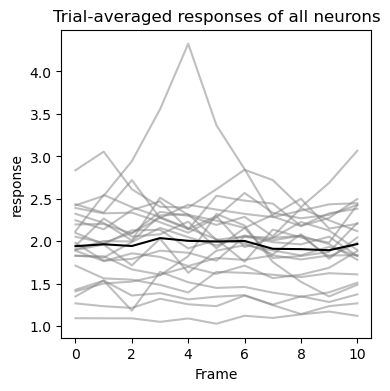

In [227]:
trial_spks = np.array(trial_spks)
print(trial_spks.shape)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
# plot all neurons
for i in range(n_neurons):
    ax.plot(trial_spks[:, i, :].mean(0), label=f'neuron {i}', color='gray', alpha=0.5)
# plot the mean
ax.plot(trial_spks.mean(0).mean(0), label='mean', color='black')
# ax.legend()
ax.set_xlabel('Frame')
ax.set_ylabel('response')
ax.set_title('Trial-averaged responses of all neurons')
plt.show()

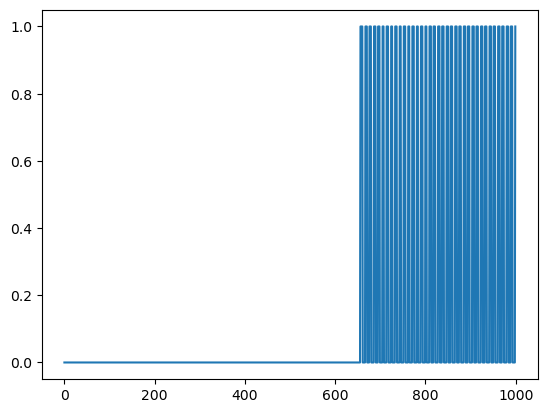

In [198]:
plt.plot(trial_flag[1000:2000])

In [214]:
np.argsort(test_fev)[0]

12

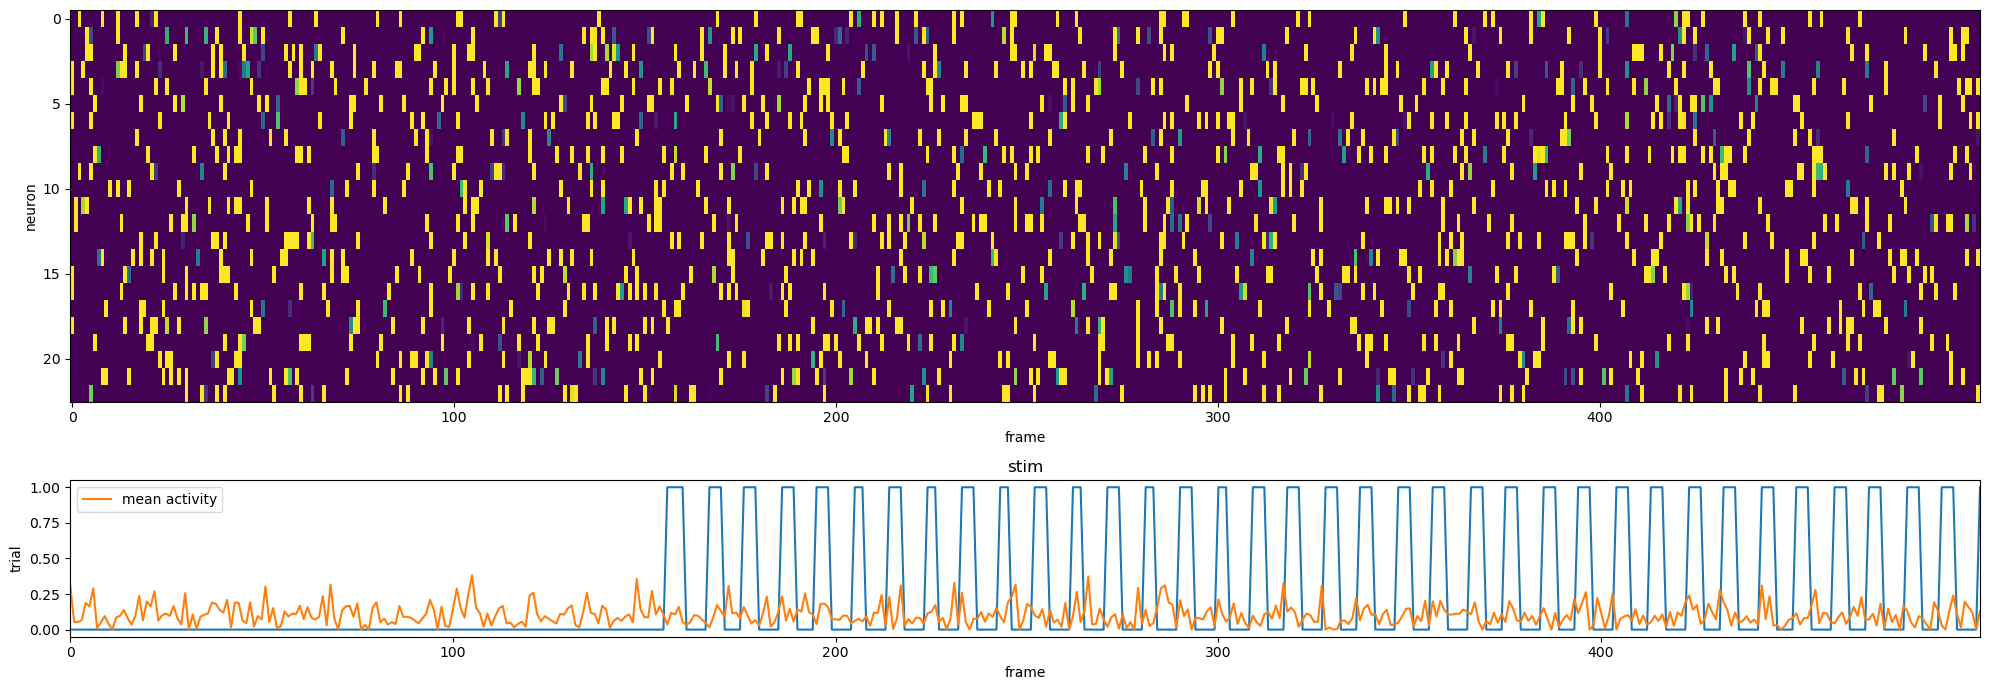

In [218]:
raw_spks.shape
fig, ax = plt.subplots(2, 1, figsize=(20, 7), height_ratios=[5, 2])
trange = np.arange(1500, 2000)
isort_neuron = np.argsort(test_fev)
ax[0].imshow(raw_spks[isort_neuron][:, trange], aspect='auto', vmin=0, vmax=5)
ax[0].set_xlabel('frame')
ax[0].set_ylabel('neuron')
ax[1].plot(trial_flag[trange])
ax[1].set_xlim(0, trange[-1]-trange[0])
ax[1].set_xlabel('frame')
ax[1].set_ylabel('trial')
ax[1].set_title('stim')
ax[1].plot(raw_spks[isort_neuron][:, trange].mean(axis=0) / 20, label='mean activity')
ax[1].legend()
# tight_layout automatically adjusts subplot params so that the subplot(s) fits in to the figure area.
plt.tight_layout()

Text(0.5, 0, 'trial')

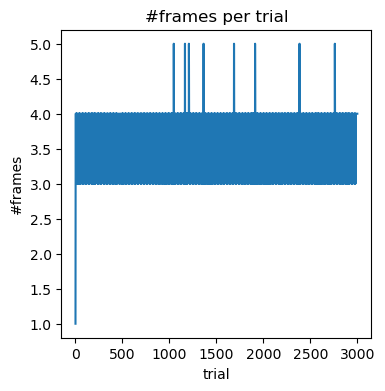

In [154]:
fig, axs = plt.subplots(1, 1, figsize=(4, 4))
plt.plot(nframes)
plt.title('#frames per trial')
plt.ylabel('#frames')
plt.xlabel('trial')

In [206]:
def fev_new(spks):
    """
    Calculate the fraction of explainable variance (FEV) for each neuron.

    Parameters:
    ----------
    spks : list of numpy.ndarray
        List of n_images arrays, each of shape (n_repeats, n_neurons), where 
        different images might have different numbers of repeats.

    Returns:
    -------
    fev : numpy.ndarray, shape (n_neurons,)
        Fraction of explainable variance for each neuron.
    """
    n_images = len(spks)

    # calculate total variance of each neuron
    total_var = np.var(np.vstack(spks), axis=0, ddof=1) # shape (n_neurons,)
    # print(total_var)

    # calculate noise variance and variance explained of each neuron
    noise_var = []
    for i in range(n_images):
        noise_var.append(np.var(spks[i], axis=0, ddof=1))
    # print(noise_var)
    noise_var = np.vstack(noise_var).mean(axis=0) # shape (n_neurons,)
    # print(noise_var)
    
    # calculate explainable variance of each neuron
    fev = (total_var - noise_var) / total_var # shape (n_neurons,)

    return fev

In [205]:
spks_rep1 = spks[:, itest_rep1]
spks_rep2 = spks[:, itest_rep2]

itest = np.hstack((itest_rep1, itest_rep2))
istim_test = np.hstack((test_ids, test_ids))

spks_test = spks[:, itest]
print(spks_test.shape)
print(istim_test.shape, istim_test.min(), istim_test.max())

(23, 1000)
(1000,) 0 499


Text(0, 0.5, 'count')

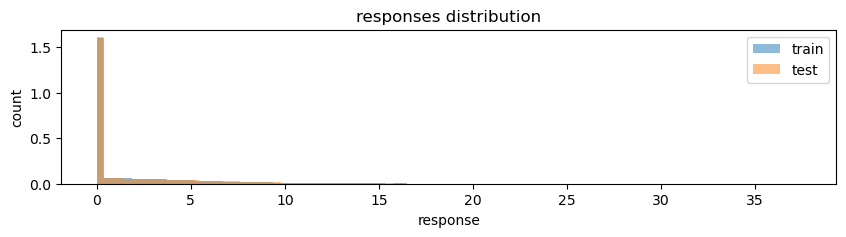

In [207]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2))
plt.hist(spks[:, :2500].flatten(), bins=100, label='train', alpha=0.5, density=True)
plt.hist(spks_test.flatten(), bins=100, label='test', alpha=0.5, density=True)
plt.legend()
plt.title('responses distribution')
plt.xlabel('response')
plt.ylabel('count')

In [208]:
# calculate FEV
from minimodel import metrics
n_unique_img = len(np.unique(istim_test))
spks_test_list = []
# ineuron = np.arange(2)
for i in range(n_unique_img):
    spks_test_list.append(spks_test[:,istim_test == i].T)

test_fev = fev_new(spks_test_list)
print('test FEV:', test_fev)

test FEV: [-0.07601071 -0.03840703  0.12462398  0.00201387 -0.06358821  0.00245515
 -0.02569261  0.02709545 -0.01273416  0.01372354  0.00568957 -0.06027256
 -0.08372382  0.03237215 -0.00945513 -0.01021235 -0.03867998 -0.08248149
  0.0401435  -0.02351327  0.0354959  -0.0816772   0.04968822]


Text(0.5, 1.0, 'FEV (mean=-0.01), NN=23')

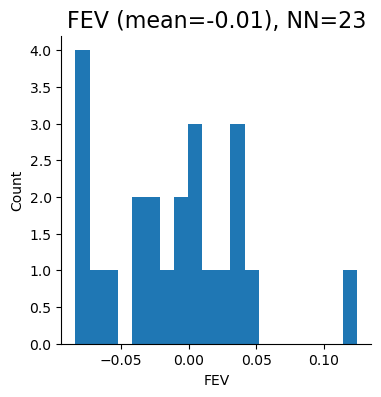

In [168]:
fig, ax = plt.subplots(1, 1, figsize=(4,4))
ax.hist(test_fev, bins=20)
ax.set_xlabel('FEV')
ax.set_ylabel('Count')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title(f'FEV (mean={test_fev.mean():.2f}), NN={n_neurons}', fontsize=16)

# decide frame lag

In [15]:

frame_lag = 1
fev_all = []
for frame_lag in range(-2, 8):
    spks = np.zeros((n_neurons, n_trials))
    for i in range(n_trials):
        trial_start = trial_start_time[i]
        trial_end = trial_end_time[i]
        trial_start_iframe = np.where(timestamps >= trial_start)[0][0] + frame_lag
        trial_end_iframe = np.where(timestamps <= trial_end)[0][-1] + frame_lag
        spks[:, i] = raw_spks[:, trial_start_iframe:trial_end_iframe].mean(axis=1)
    # print(spks.shape, spks.min(), spks.max())

    from scipy.stats import zscore
    # ss_z = zscore(ss, 1)
    # cc = (ss_z[0] * ss_z[1]).mean(0)

    spks_rep1 = spks[:, itest_rep1]
    spks_rep2 = spks[:, itest_rep2]

    itest = np.hstack((itest_rep1, itest_rep2))
    istim_test = np.hstack((test_ids, test_ids))

    spks_test = spks[:, itest]
    print(spks_test.shape)
    print(istim_test.shape, istim_test.min(), istim_test.max())

    from approxineuro.neural_utils import sig_variance
    fev = sig_variance(spks_test, istim_test)
    print(fev.mean())
    fev_all.append(fev.mean())

(107, 272)
(272,) 5 495
0.009592617585709827
(107, 272)
(272,) 5 495
0.0378180637282491
(107, 272)
(272,) 5 495
0.07062081817370133
(107, 272)
(272,) 5 495
0.10365157910062817
(107, 272)
(272,) 5 495
0.08817188696898846
(107, 272)
(272,) 5 495
0.07806986785790793
(107, 272)
(272,) 5 495
0.04393542289463304
(107, 272)
(272,) 5 495
0.014879189928175135
(107, 272)
(272,) 5 495
0.0021042023247956993
(107, 272)
(272,) 5 495
-0.003242793001958662


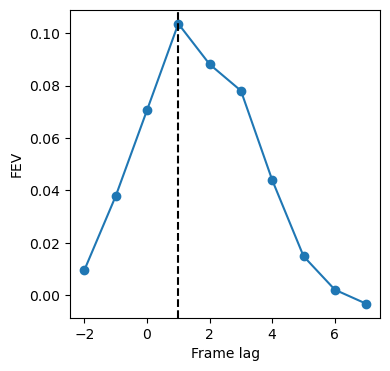

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(4,4))
ax.plot(np.arange(-2, 8), fev_all, 'o-')
ax.set_xlabel('Frame lag')
ax.set_ylabel('FEV')
ax.axvline(1, color='k', linestyle='--')

# save data

In [15]:
print(spks.shape, spks.min(), spks.max())
print(itrain.shape, ival.shape, itest_rep1.shape, itest_rep2.shape)
print(image_ids.shape)
print(images.shape)
print(fev.shape)

(107, 1546) 0.0 1160.7076416015625
(1020,) (254,) (136,) (136,)
(1546,)
(30000, 66, 77)
(107,)


In [17]:
images_train = images[image_ids[itrain]]
images_val = images[image_ids[ival]]
images_test = images[image_ids[itest_rep1]]

print(images_train.shape, images_val.shape, images_test.shape)

spks_train = spks[:, itrain]
spks_val = spks[:, ival]
spks_test = np.array((spks[:, itest_rep1], spks[:, itest_rep2]))
print(spks_train.shape, spks_val.shape, spks_test.shape)

data_dict = {
    'images_train': images_train,
    'images_val': images_val,
    'images_test': images_test,
    'spks_train': spks_train,
    'spks_val': spks_val,
    'spks_test': spks_test,
    'fev': fev
}

np.savez('data/sc_processed_data.npz', **data_dict)

(1020, 66, 77) (254, 66, 77) (136, 66, 77)
(107, 1020) (107, 254) (2, 107, 136)


# preprocess the data (FEV when slow it down from 30Hz to 15Hz)

In [19]:
# record at 30 Hz
# 6 images per trial (3 natural + 3 grayscale)
trial_start_time = np.load(os.path.join(data_dir, 'natural.startTime.npy'))
print('trial start time:', trial_start_time.shape, trial_start_time.min(), trial_start_time.max())

trial_end_time = np.load(os.path.join(data_dir, 'natural.endTime.npy'))
print('trial end time:', trial_end_time.shape, trial_end_time.min(), trial_end_time.max())

timestamps = np.load(os.path.join(data_dir, 'calcium.timestamps.npy'))
print('timestamps:', timestamps.shape, timestamps.min(), timestamps.max())
timestamps = timestamps[::2]
print('timestamps:', timestamps.shape, timestamps.min(), timestamps.max())

n_trials = trial_start_time.shape[0]    
assert trial_end_time.shape[0] == trial_start_time.shape[0]

trial start time: (1546, 1) 310.18600000000004 799.3810000000001
trial end time: (1546, 1) 310.357 799.54
timestamps: (35657, 1) 5.081 1201.714
timestamps: (17829, 1) 5.081 1201.714


In [20]:
# load the calcium data
root = 'data/'
n = 0
raw_spks = np.load(os.path.join(root, 'suite2p', 'plane%d'%n, 'spks.npy'), allow_pickle=True)    
icell = np.load(os.path.join(root, 'suite2p', 'plane%d'%n, 'iscell.npy'))[:,0]
raw_spks = raw_spks[icell>0.5]
n_neurons, n_frames = raw_spks.shape
print(raw_spks.shape)

raw_spks = raw_spks[:, ::2]
n_frames = raw_spks.shape[1]
print(raw_spks.shape)

(107, 35657)
(107, 17829)


In [21]:
spks = np.zeros((n_neurons, n_trials))
frame_lag = 1
for i in range(n_trials):
    trial_start = trial_start_time[i]
    trial_end = trial_end_time[i]
    trial_start_iframe = np.where(timestamps >= trial_start)[0][0] + frame_lag
    trial_end_iframe = np.where(timestamps <= trial_end)[0][-1] + frame_lag
    spks[:, i] = raw_spks[:, trial_start_iframe:trial_end_iframe].mean(axis=1)
print(spks.shape, spks.min(), spks.max())

(107, 1546) 0.0 3246.86474609375


In [22]:
spks_rep1 = spks[:, itest_rep1]
spks_rep2 = spks[:, itest_rep2]

itest = np.hstack((itest_rep1, itest_rep2))
istim_test = np.hstack((test_ids, test_ids))

spks_test = spks[:, itest]
print(spks_test.shape)
print(istim_test.shape, istim_test.min(), istim_test.max())

from approxineuro.neural_utils import sig_variance
fev = sig_variance(spks_test, istim_test)
print(fev.mean())

(107, 272)
(272,) 5 495
0.05552516318840842


Text(0.5, 1.0, 'FEV (mean=0.06), NN=107\n15Hz, frame lag=1')

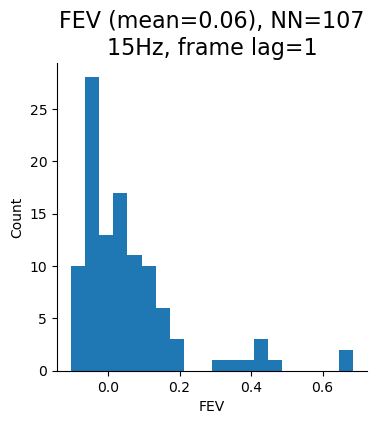

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(4,4))
ax.hist(fev, bins=20)
ax.set_xlabel('FEV')
ax.set_ylabel('Count')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title(f'FEV (mean={fev.mean():.2f}), NN={n_neurons}\n15Hz, frame lag={frame_lag}', fontsize=16)

# preprocee the data (FEV when showing stims faster)

In [24]:
# record at 30 Hz
# 6 images per trial (3 natural + 3 grayscale)
trial_start_time = np.load(os.path.join(data_dir, 'natural.startTime.npy'))
print('trial start time:', trial_start_time.shape, trial_start_time.min(), trial_start_time.max())

trial_end_time = np.load(os.path.join(data_dir, 'natural.endTime.npy'))
print('trial end time:', trial_end_time.shape, trial_end_time.min(), trial_end_time.max())

timestamps = np.load(os.path.join(data_dir, 'calcium.timestamps.npy'))
print('timestamps:', timestamps.shape, timestamps.min(), timestamps.max())

n_trials = trial_start_time.shape[0]    
assert trial_end_time.shape[0] == trial_start_time.shape[0]

trial start time: (1546, 1) 310.18600000000004 799.3810000000001
trial end time: (1546, 1) 310.357 799.54
timestamps: (35657, 1) 5.081 1201.714


In [25]:
# load the calcium data
root = 'data/'
n = 0
raw_spks = np.load(os.path.join(root, 'suite2p', 'plane%d'%n, 'spks.npy'), allow_pickle=True)    
icell = np.load(os.path.join(root, 'suite2p', 'plane%d'%n, 'iscell.npy'))[:,0]
raw_spks = raw_spks[icell>0.5]
n_neurons, n_frames = raw_spks.shape
print(raw_spks.shape)

(107, 35657)


In [26]:
spks = np.zeros((n_neurons, n_trials))
frame_lag = 3
for i in range(n_trials):
    trial_start = trial_start_time[i]
    trial_end = trial_end_time[i]
    trial_start_iframe = np.where(timestamps >= trial_start)[0][0] + frame_lag
    trial_end_iframe = np.where(timestamps <= trial_end)[0][-1] + frame_lag
    nframes = trial_end_iframe - trial_start_iframe
    nframes = int(nframes / 2)
    spks[:, i] = raw_spks[:, trial_start_iframe:(trial_start_iframe+nframes)].mean(axis=1)
print(spks.shape, spks.min(), spks.max())

(107, 1546) 0.0 2682.85595703125


In [27]:
spks_rep1 = spks[:, itest_rep1]
spks_rep2 = spks[:, itest_rep2]

itest = np.hstack((itest_rep1, itest_rep2))
istim_test = np.hstack((test_ids, test_ids))

spks_test = spks[:, itest]
print(spks_test.shape)
print(istim_test.shape, istim_test.min(), istim_test.max())

from approxineuro.neural_utils import sig_variance
fev = sig_variance(spks_test, istim_test)
print(fev.mean())

(107, 272)
(272,) 5 495
0.062168297037964726


Text(0.5, 1.0, 'FEV (mean=0.06), NN=107\nfirt half frames, frame lag=3')

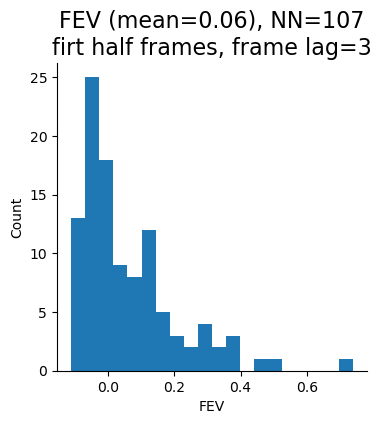

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(4,4))
ax.hist(fev, bins=20)
ax.set_xlabel('FEV')
ax.set_ylabel('Count')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title(f'FEV (mean={fev.mean():.2f}), NN={n_neurons}\nfirt half frames, frame lag={frame_lag}', fontsize=16)

In [29]:
frame_lag = 1
fev_all = []
for frame_lag in range(-2, 8):
    spks = np.zeros((n_neurons, n_trials))
    for i in range(n_trials):
        trial_start = trial_start_time[i]
        trial_end = trial_end_time[i]
        trial_start_iframe = np.where(timestamps >= trial_start)[0][0] + frame_lag
        trial_end_iframe = np.where(timestamps <= trial_end)[0][-1] + frame_lag
        nframes = trial_end_iframe - trial_start_iframe
        nframes = int(nframes / 2)
        spks[:, i] = raw_spks[:, trial_start_iframe:(trial_start_iframe+nframes)].mean(axis=1)
    # print(spks.shape, spks.min(), spks.max())

    from scipy.stats import zscore
    # ss_z = zscore(ss, 1)
    # cc = (ss_z[0] * ss_z[1]).mean(0)

    spks_rep1 = spks[:, itest_rep1]
    spks_rep2 = spks[:, itest_rep2]

    itest = np.hstack((itest_rep1, itest_rep2))
    istim_test = np.hstack((test_ids, test_ids))

    spks_test = spks[:, itest]
    print(spks_test.shape)
    print(istim_test.shape, istim_test.min(), istim_test.max())

    from approxineuro.neural_utils import sig_variance
    fev = sig_variance(spks_test, istim_test)
    print(fev.mean())
    fev_all.append(fev.mean())

(107, 272)
(272,) 5 495
0.008521099381863384
(107, 272)
(272,) 5 495
-0.006398861105969146
(107, 272)
(272,) 5 495
0.0019869233872394023
(107, 272)
(272,) 5 495
0.041466123717240407
(107, 272)
(272,) 5 495
0.06108032788785574
(107, 272)
(272,) 5 495
0.062168297037964726
(107, 272)
(272,) 5 495
0.028919855279196476
(107, 272)
(272,) 5 495
0.017267992324864853
(107, 272)
(272,) 5 495
0.010793565900478655
(107, 272)
(272,) 5 495
-0.004501359056437486


Text(0, 0.5, 'FEV')

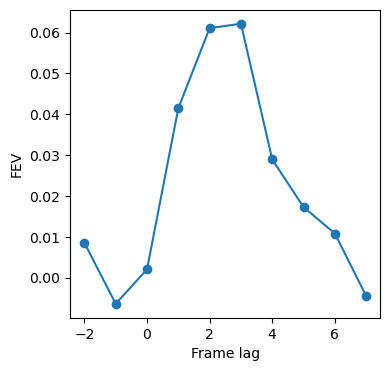

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(4,4))
ax.plot(np.arange(-2, 8), fev_all, 'o-')
ax.set_xlabel('Frame lag')
ax.set_ylabel('FEV')
# ax.axvline(1, color='k', linestyle='--')